In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Load and Preprocess MNIST Dataset

The MNIST dataset consists of **handwritten digits (0–9)**.

Each image size:
28 × 28 pixels

We convert images to tensors using **ToTensor()** which scales pixel values from **0–255 → 0–1**.

DataLoader helps in:
- batching
- shuffling
- efficient training

In [2]:
batch_size = 128

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 489kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.1MB/s]


# Define Hyperparameters

We define important training parameters.

Input dimension:
28 × 28 = **784**

Hidden layer size controls model capacity.

Latent dimension represents the **compressed representation of data**.

We will try **different latent dimensions** to observe how reconstruction quality changes.

In [3]:
input_dim = 784
hidden_dim = 400
learning_rate = 1e-3
epochs = 10

latent_dims = [2, 10, 20, 50]

# Define Variational Autoencoder Model

The VAE has three main components:

### 1 Encoder
Transforms input image into:
- Mean (μ)
- Log Variance (log σ²)

### 2 Reparameterization Trick
Instead of directly sampling z from distribution:

z ~ N(μ, σ²)

We compute:

z = μ + σ * ε  
ε ~ N(0,1)

This allows gradients to flow during backpropagation.

### 3 Decoder
Transforms latent vector z back into reconstructed image.

In [4]:
class VAE(nn.Module):

    def __init__(self, latent_dim):
        super(VAE, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = self.relu(self.fc2(z))
        return self.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        return reconstruction, mu, logvar

# Define VAE Loss Function

The VAE loss consists of two components.

### 1 Reconstruction Loss

Measures how similar reconstructed image is to original image.

We use **Binary Cross Entropy (BCE)**.

### 2 KL Divergence Loss

Ensures the latent distribution stays close to a **standard normal distribution N(0,1)**.

### Total VAE Loss

Total Loss = Reconstruction Loss + KL Divergence

In [5]:
def loss_function(recon_x, x, mu, logvar):

    reconstruction_loss = nn.functional.binary_cross_entropy(
        recon_x, x, reduction='sum'
    )

    kl_divergence = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    return reconstruction_loss + kl_divergence, reconstruction_loss, kl_divergence

# Training the Variational Autoencoder

The training loop performs the following steps:

1. Forward pass through encoder and decoder
2. Compute reconstruction and KL divergence loss
3. Combine losses to form total loss
4. Perform backpropagation
5. Update weights using Adam optimizer

We also train the model using **different latent dimensions** to compare performance.

In [6]:
trained_models = {}

for latent_dim in latent_dims:

    print("\nTraining VAE with Latent Dimension =", latent_dim)

    model = VAE(latent_dim)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):

        total_loss = 0
        total_recon_loss = 0
        total_kl_loss = 0

        for data, _ in train_loader:

            data = data.view(-1,784)

            optimizer.zero_grad()

            reconstruction, mu, logvar = model(data)

            loss, recon_loss, kl_loss = loss_function(
                reconstruction, data, mu, logvar
            )

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        avg_recon = total_recon_loss / len(train_loader.dataset)
        avg_kl = total_kl_loss / len(train_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Average Total Loss: {avg_loss:.4f}")
        print(f"Average Reconstruction Loss: {avg_recon:.4f}")
        print(f"Average KL Divergence Loss: {avg_kl:.4f}")
        print("-"*40)

    trained_models[latent_dim] = model


Training VAE with Latent Dimension = 2
Epoch 1/10
Average Total Loss: 189.4952
Average Reconstruction Loss: 183.7013
Average KL Divergence Loss: 5.7940
----------------------------------------
Epoch 2/10
Average Total Loss: 168.2365
Average Reconstruction Loss: 162.9393
Average KL Divergence Loss: 5.2972
----------------------------------------
Epoch 3/10
Average Total Loss: 163.7748
Average Reconstruction Loss: 158.4651
Average KL Divergence Loss: 5.3097
----------------------------------------
Epoch 4/10
Average Total Loss: 161.5180
Average Reconstruction Loss: 156.1553
Average KL Divergence Loss: 5.3627
----------------------------------------
Epoch 5/10
Average Total Loss: 160.0606
Average Reconstruction Loss: 154.6423
Average KL Divergence Loss: 5.4183
----------------------------------------
Epoch 6/10
Average Total Loss: 158.8546
Average Reconstruction Loss: 153.3735
Average KL Divergence Loss: 5.4811
----------------------------------------
Epoch 7/10
Average Total Loss: 157.8

# Interpretation of Training Results

The training results show that the **total loss decreases steadily across epochs**, indicating that the VAE model is learning effectively.  
For **latent dimension = 2**, the reconstruction loss remains relatively high because the model compresses the data into a very small latent space.  
When the latent dimension increases to **10, 20, and 50**, the reconstruction loss decreases significantly, meaning the model can preserve more information about the images.  
The **KL divergence increases with larger latent dimensions** since more latent variables contribute to the regularization term.  
Overall, models with **latent dimensions 20 and 50 achieve the lowest total loss and best reconstruction quality**.  
This shows that increasing latent space improves performance up to a certain point, after which improvements become minimal.

# Visualizing Reconstructed Images

After training the model, we compare:

Top row → Original Images  
Bottom row → Reconstructed Images

This helps us evaluate how well the VAE has learned the data distribution.

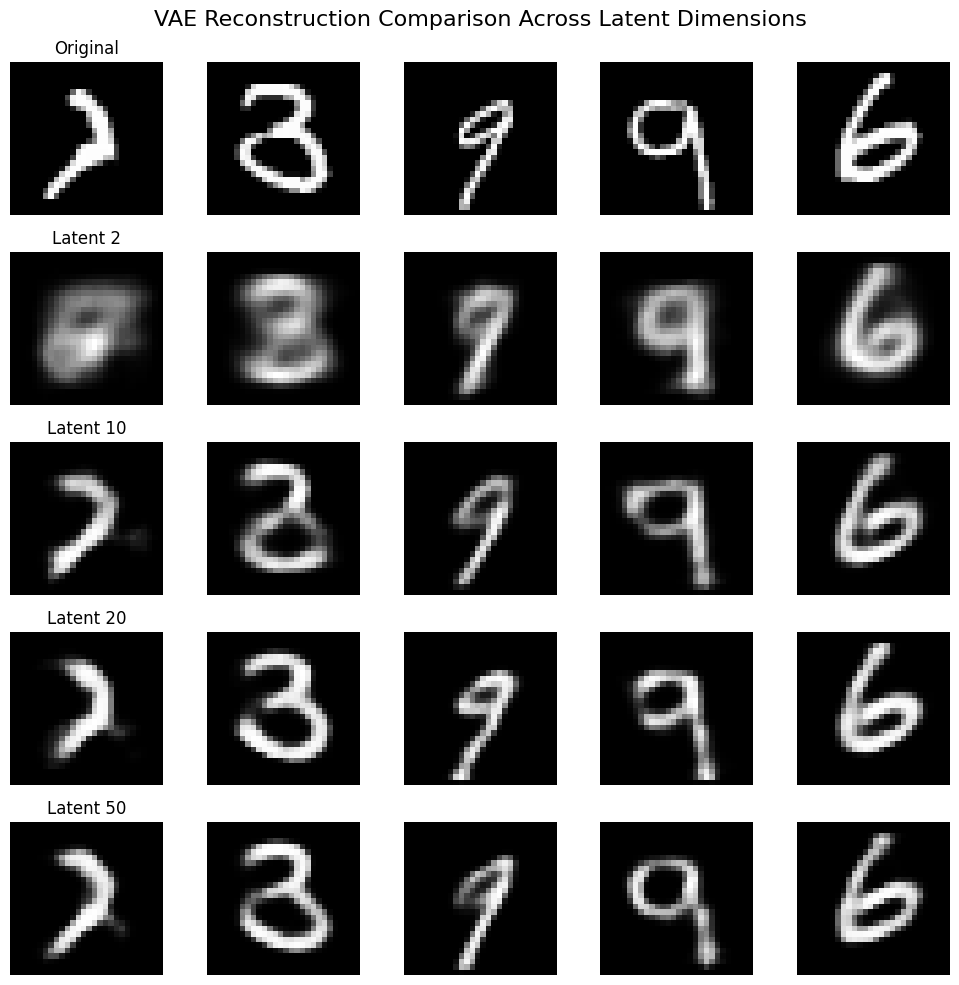

In [16]:
data_iter = iter(train_loader)
images, _ = next(data_iter)

images_flat = images.view(-1,784)

rows = len(latent_dims) + 1
cols = 5

fig, axes = plt.subplots(rows, cols, figsize=(10,10))
fig.suptitle("VAE Reconstruction Comparison Across Latent Dimensions", fontsize=16)

for i in range(cols):
    axes[0,i].imshow(images[i].numpy().squeeze(), cmap='gray')
    axes[0,i].axis('off')

axes[0,0].set_title("Original", fontsize=12)

for row, latent_dim in enumerate(latent_dims, start=1):

    model = trained_models[latent_dim]

    recon, _, _ = model(images_flat)
    recon = recon.view(-1,1,28,28)

    for i in range(cols):
        axes[row,i].imshow(recon[i].detach().numpy().squeeze(), cmap='gray')
        axes[row,i].axis('off')

    axes[row,0].set_title(f"Latent {latent_dim}", fontsize=12)

plt.tight_layout()
plt.show()

# Interpretation of VAE Reconstruction Across Latent Dimensions

The figure compares the **original MNIST images** with the **reconstructed images produced by Variational Autoencoders (VAEs)** trained with different latent dimensions (2, 10, 20, and 50).

Each row represents the reconstruction results from a model with a specific **latent space size**.

---

## 1. Original Images

The first row shows the **original MNIST digits** from the dataset.  
These images act as the **ground truth** for comparison with the reconstructed outputs.

Example digits shown:

1, 3, 9, 9, 6

---

## 2. Latent Dimension = 2

When the latent space size is **2**, the model compresses each image into only **two numerical values**.

### Observations

- Reconstructions appear **blurry**
- Digit shapes are still somewhat recognizable
- Fine details and edges are lost

### Reason

This occurs because the model is forced to compress the image information into **very few variables**, causing significant **information loss**.

---

## 3. Latent Dimension = 10

When the latent dimension increases to **10**, reconstruction quality improves noticeably.

### Observations

- Digits become **clearer**
- Edges are sharper
- The structure of the digits is more accurate

### Reason

A larger latent space allows the model to **store more meaningful information** about the input images.

---

## 4. Latent Dimension = 20

With **20 latent variables**, the reconstructions become **very close to the original images**.

### Observations

- Digits are almost identical to the originals
- Very little blurring
- Good preservation of digit structure

### Interpretation

This suggests that **around 20 latent dimensions are sufficient to capture most of the important information in MNIST digits**.

---

## 5. Latent Dimension = 50

Increasing the latent dimension further to **50** does not significantly improve the reconstruction quality.

### Observations

- Reconstructions are very similar to those with latent dimension 20
- Only minor improvements are observed

### Reason

MNIST images are relatively simple, so **additional latent variables do not add much useful information**.

---

# Conclusion

This experiment demonstrates that **latent space size plays an important role in Variational Autoencoders**.

- Smaller latent dimensions lead to **strong compression and blurry reconstructions**.
- Increasing the latent dimension improves reconstruction quality.
- However, after a certain point (around **20 latent variables for MNIST**), further increasing the latent space provides **minimal improvement**.

Therefore, a latent dimension of **around 20 provides a good balance between compression and reconstruction quality for MNIST images**.

# Latent Space Visualization (2D)

Since we trained a VAE with **latent dimension = 2**, the encoder maps every image
into a point in a **2D latent space**.

By plotting these points we can observe how the model organizes different digits.

Each point represents an MNIST image and colors represent digit labels.

In [8]:
import numpy as np

model = trained_models[2]

latent_points = []
labels = []

with torch.no_grad():

    for data, target in train_loader:

        data = data.view(-1,784)

        mu, logvar = model.encode(data)

        latent_points.append(mu)
        labels.append(target)

latent_points = torch.cat(latent_points).numpy()
labels = torch.cat(labels).numpy()

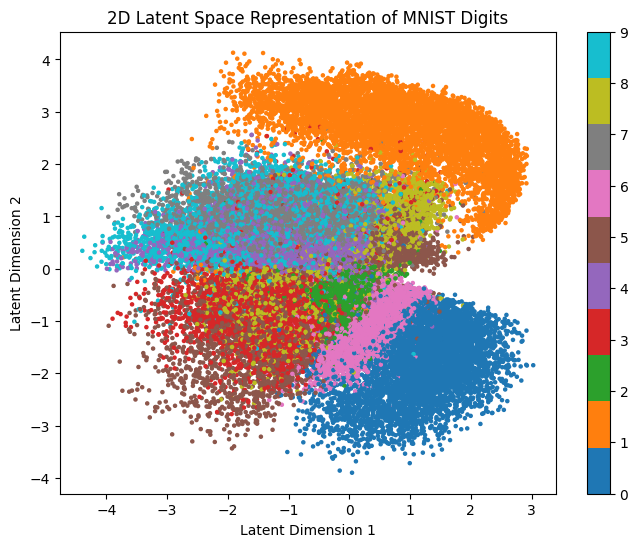

In [9]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    latent_points[:,0],
    latent_points[:,1],
    c=labels,
    cmap="tab10",
    s=5
)

plt.colorbar(scatter)

plt.title("2D Latent Space Representation of MNIST Digits")

plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")

plt.show()

# Interpretation of 2D Latent Space Representation of MNIST Digits

The figure shows the **2D latent space representation learned by the Variational Autoencoder (VAE)**. Each point in the plot corresponds to a digit image from the MNIST dataset encoded into the latent space.

The coordinates of each point represent the values of the two latent variables learned by the encoder.

Different colors represent **different digit classes (0–9)**.

---

## Observations

### 1. Formation of Digit Clusters
Digits with similar structures tend to appear **close to each other in the latent space**.  
This indicates that the VAE has learned meaningful features of the handwritten digits.

For example:
- Some digits form compact clusters
- Similar-looking digits appear near each other

---

### 2. Overlapping Regions
Some clusters overlap slightly.  
This occurs because certain digits share similar shapes.

Examples:
- **3, 5, and 8** often appear close because they have curved structures.
- **1 and 7** may appear near each other due to similar vertical strokes.

This overlap indicates that the model captures **shared visual characteristics** between digits.

---

### 3. Continuous Latent Space Structure
The latent space is **continuous and smooth**, meaning nearby points represent similar images.

This property allows the VAE to:
- Generate new digits
- Interpolate between digits
- Produce smooth transitions between digit styles

---

## What This Shows About the VAE

The visualization demonstrates that the VAE successfully learns a **structured latent representation of the data**.

Instead of memorizing images, the model organizes them according to **underlying visual features**, such as:
- stroke thickness
- curvature
- orientation
- digit structure

---

# Conclusion

The 2D latent space visualization confirms that the Variational Autoencoder has learned a **meaningful and structured representation of handwritten digits**.  
Similar digits are grouped together in the latent space, while different digits occupy separate regions. This indicates that the VAE effectively captures the underlying patterns present in the MNIST dataset.